# Retail Rocket: Data cleaning, Exploratory Data Analysis and Feature engineering

## 1. Introduction and data loading

This notebook prepares the Retail Rocket dataset for the same two recommender systems that were built from scratch for Diginetica: matrix factorization (SVD, technique A) and item-based collaborative filtering (Item-KNN, technique D). Retail Rocket is an e-commerce dataset released by the company Retail Rocket on Kaggle, containing about 2.76 million anonymized behaviour events from roughly 1.4 million visitors over 235,061 items, as reported in the dataset documentation.

The structure of this notebook follows the Diginetica notebook so that the two datasets can be compared directly, but a few choices are adapted because Retail Rocket differs from Diginetica in three ways that matter for the modelling. First, every event has a real `visitorid`, so the user unit can be the visitor instead of the session. Second, there are three event types (view, addtocart, transaction) instead of two, which changes how the proxy rating is built. Third, the dataset does not provide a clean price column, so the price-based analysis used for Diginetica is replaced by an analysis of the view–cart–purchase funnel. Each of these points is examined in the EDA before any cleaning decision is made.

In this notebook I clean the data, explore it, engineer the features needed for collaborative filtering, and save a single processed interaction file. That file is then loaded by the modelling notebook.

### 1.1 Extract and load the raw files

The dataset is downloaded as a zip archive and extracted. Unlike the Diginetica files, the Retail Rocket files are normal comma-separated CSVs, so no `sep` argument is needed. Two files are loaded here: `events.csv`, which holds every behaviour event, and `category_tree.csv`, which holds the category hierarchy. The two `item_properties` files are very large and contain only hashed property–value pairs, so they are not loaded now. This is a deliberate scope choice: both techniques used in this project are collaborative filtering methods, which model the interaction patterns between users and items rather than item content, whereas using item attributes as features would belong to content-based filtering (Bhaumik, 2024a). Like the Diginetica price feature, this item content is therefore not used by the models, so loading the property files is deferred unless it is needed.

In [2]:
import zipfile, os

# Kaggle exports the Retail Rocket data as a single zip. Adjust the name if your download differs.
zip_name = "archive retailrocket.zip"

with zipfile.ZipFile(zip_name) as z:
    z.extractall("retailrocket")

# Show which files were extracted.
print(os.listdir("retailrocket"))

['category_tree.csv', 'events.csv', 'item_properties_part1.csv', 'item_properties_part2.csv']


In [3]:
import pandas as pd

# events.csv holds one row per behaviour event (view, addtocart or transaction).
events = pd.read_csv("retailrocket/events.csv")
# category_tree.csv holds the parent-child links between item categories.
category_tree = pd.read_csv("retailrocket/category_tree.csv")

print("EVENTS:", events.columns.tolist())
print(events.head(), "\n")
print("CATEGORY TREE:", category_tree.columns.tolist())
print(category_tree.head())

EVENTS: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN 

CATEGORY TREE: ['categoryid', 'parentid']
   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0


### 1.2 Clean the column names

The raw files use names like `visitorid` and `itemid`. I rename these to clear, consistent names (`user_id`, `item_id`, etc.) so the rest of the notebook is easier to read and matches the names used in the modelling notebook. This is the first cleaning step, done before the analysis so that all later code uses the same names. The `visitorid` is renamed to `user_id` because, as motivated in the introduction and confirmed in section 2.4, the visitor is used as the user unit for this dataset.

In [4]:
# Rename the columns to clear, consistent names, matching the style used for Diginetica.
events = events.rename(columns={'visitorid': 'user_id', 'itemid': 'item_id', 'transactionid': 'transaction_id', 'timestamp': 'ts'})
category_tree = category_tree.rename(columns={'categoryid': 'category_id', 'parentid': 'parent_id'})

# Confirm the new column names.
print("Events:", events.columns.tolist())
print("Category tree:", category_tree.columns.tolist())

Events: ['ts', 'user_id', 'event', 'item_id', 'transaction_id']
Category tree: ['category_id', 'parent_id']


## 2. Exploratory Data Analysis

In this section I explore the data before making any cleaning or modelling decisions. The goal is to understand the size of the data, how the events split over the three event types, the shape of the main distributions, and whether visitors return across time. The findings here are used to justify the cleaning and filtering choices made later in the notebook.

### 2.1 Descriptive statistics

First, the raw event table is described to understand its size and shape. I focus on the things that matter for a recommender system: how many events each visitor produces (visitor activity, which plays the role that session length played for Diginetica), how often each item is interacted with (item popularity), and how the events split over the three event types (view, addtocart, transaction). The event-type split is examined here because it determines how the proxy rating is built later. The timestamps are also converted to a readable date range to see the period the data covers.

In [5]:
# Basic size of the event table.
print("Event records:", len(events))
print("Unique visitors:", events['user_id'].nunique())
print("Unique items:", events['item_id'].nunique())

# How the events split over the three event types (the behaviour funnel).
print("\nEvent type counts:")
print(events['event'].value_counts())

# Visitor activity = how many events each visitor produces (Retail Rocket's analogue of session length).
events_per_visitor = events.groupby('user_id').size()
print("\nEvents per visitor:")
print(events_per_visitor.describe())

# Item popularity = how many events each item receives.
item_popularity = events.groupby('item_id').size()
print("\nEvents per item (popularity):")
print(item_popularity.describe())

# The timestamps are Unix milliseconds; convert the min and max to see the period the data covers.
ts = pd.to_datetime(events['ts'], unit='ms')
print("\nDate range:", ts.min(), "to", ts.max())

Event records: 2756101
Unique visitors: 1407580
Unique items: 235061

Event type counts:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Events per visitor:
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

Events per item (popularity):
count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64

Date range: 2015-05-03 03:00:04.384000 to 2015-09-18 02:59:47.788000


### Interpretation

The totals match the dataset documentation exactly: 2,756,101 events from 1,407,580 visitors over 235,061 items. This confirms that the data was loaded completely and correctly. The data covers a period of about four and a half months, from 3 May 2015 to 18 September 2015, which is long enough to contain repeated visits but short enough that item popularity is unlikely to shift dramatically over time.

The three event types form a clear behaviour funnel. Views dominate with 2,664,312 records (96.7% of all events), followed by 69,332 add-to-cart events (2.5%) and only 22,457 transactions (0.8%). Put differently, about 2.6% of views lead to an add-to-cart, and about 32% of add-to-carts lead to a transaction. Each step down the funnel is both rarer and a stronger signal of intent, which is exactly the situation the lecture on implicit feedback describes, where a stronger action should count more than a weaker one (Bhaumik, 2024b). This supports the ordinal proxy rating used in section 3, where a view is weighted 1, an add-to-cart 2, and a transaction 3.

Visitor activity is very low: the median visitor produces only one event and the mean is just 1.96, while a few extreme visitors are far more active (up to 7,757 events). This means most visitors give almost no information about their preferences, and that many visitors will be removed by the minimum-interaction filter applied later in the notebook. Item popularity is more spread out: the median item is interacted with 3 times while a small number of items receive far more (up to 3,412), which is the long-tail pattern typical for e-commerce data and is examined visually in section 2.3. Together these two observations already point to an extremely sparse interaction matrix, which is the central challenge for the collaborative filtering models.

**Filter impact preview.** Because the median visitor produces only one event, the minimum-interaction filter applied in section 4 may remove a large share of visitors. The minimum of three is needed for a reason that does not depend on the dataset: each retained visitor must keep at least one interaction in the training, validation and test set, so three is the smallest count that allows a per-visitor split. Before committing to that threshold, I check here how many visitors and how many events survive a few candidate thresholds. This is an approximation on raw event counts; the final filter in section 4 runs on the deduplicated user–item interactions, so the exact numbers shift slightly.

In [6]:
# Events per visitor was already computed above; reuse it here.
total_visitors = len(events_per_visitor)
total_events = events_per_visitor.sum()

# Check a few candidate minimum-interaction thresholds.
print(f"{'min':>4} {'visitors kept':>16} {'share visitors':>16} {'events kept':>14} {'share events':>14}")
for t in [1, 2, 3, 5]:
    keep = events_per_visitor[events_per_visitor >= t]   # visitors meeting the threshold
    v_share = len(keep) / total_visitors                 # fraction of visitors retained
    e_share = keep.sum() / total_events                  # fraction of events retained
    print(f"{t:>4} {len(keep):>16,} {v_share:>16.2%} {keep.sum():>14,} {e_share:>14.2%}")

 min    visitors kept   share visitors    events kept   share events
   1        1,407,580          100.00%      2,756,101        100.00%
   2          406,020           28.85%      1,754,541         63.66%
   3          200,028           14.21%      1,342,557         48.71%
   5           81,620            5.80%        948,537         34.42%


### Interpretation

The preview confirms that the minimum-interaction filter is aggressive on visitors but much gentler on the signal. Requiring at least three events keeps only 200,028 of the 1,407,580 visitors (14.21%), so almost six in seven visitors are dropped. The share of events kept is far higher, however: those same visitors still account for 1,342,557 events (48.71%). The gap between the two columns is the key point. Visitors are removed in large numbers because most of them produce only one event (the threshold of 1 keeps everyone), but each removed visitor takes only a single interaction with them, so nearly half of all behaviour survives. A threshold of two already shows the same effect (28.85% of visitors but 63.66% of events), and a threshold of five is stricter still (5.80% of visitors, 34.42% of events).

This supports keeping three as the minimum. Three is the smallest count that allows each retained visitor to be split across the training, validation and test set, and at that level the data still retains close to half of the observed events while removing the visitors that carry no usable preference information. The exact figures will shift slightly in section 4, because the final filter runs on deduplicated user–item interactions rather than on raw event counts, and an item-level filter is applied as well.

### 2.2 Missing values analysis

Next, I check each table for missing values. This matters because the way missing values are handled affects which records can be used. For each table I count the missing values per column. One column needs extra attention: `transaction_id` is only filled for transaction events, so I expect it to be missing for every view and add-to-cart. Rather than assume this, I verify it by cross-tabulating the event type against whether `transaction_id` is present.

In [7]:
# Count missing values per column for both tables.
print("Missing values in events:")
print(events.isna().sum(), "\n")

print("Missing values in category_tree:")
print(category_tree.isna().sum())

Missing values in events:
ts                      0
user_id                 0
event                   0
item_id                 0
transaction_id    2733644
dtype: int64 

Missing values in category_tree:
category_id     0
parent_id      25
dtype: int64


In [8]:
# transaction_id should only be filled for transaction events.
# Cross-tabulate event type against whether transaction_id is missing to confirm this.
print(pd.crosstab(events['event'], events['transaction_id'].isna(),
                  rownames=['event'], colnames=['transaction_id missing']))

transaction_id missing  False    True 
event                                 
addtocart                   0    69332
transaction             22457        0
view                        0  2664312


### Interpretation

The columns needed to build the interaction data are complete. In the events table, `ts`, `user_id`, `event` and `item_id` have no missing values at all, so no interaction rows are lost. The only column with missing values is `transaction_id`, which is empty for 2,733,644 of the 2,756,101 events. This is not missing data in the usual sense and should not be imputed: the count matches exactly the 2,664,312 view events plus the 69,332 add-to-cart events, and the 22,457 filled values match the transaction events one to one. The cross-tabulation makes this explicit, showing that `transaction_id` is present for every transaction event and absent for every view and add-to-cart event, with no exceptions. A `transaction_id` only exists when an event is an actual transaction, so its absence for views and add-to-carts is the expected behaviour of the column rather than a data-quality problem. This column is not used to build the interaction matrix, so the missingness has no effect on the modelling.

The category tree has 25 missing values in `parent_id`. These are the top-level categories, which by definition have no parent category above them. Because the category tree is not used as a feature by the interaction-based models, this missingness does not need to be imputed either. Overall, no imputation is required: the fields that drive the recommender (`user_id`, `item_id`, `event`) are fully populated, and the missing values that do exist are structural rather than accidental.

### 2.3 Distribution visualizations

Descriptive statistics give the averages, but the shape of each distribution is just as important. Three distributions are plotted: visitor activity, item popularity, and the split over the three event types. I do this to see how skewed the data is, because heavy skew is common in e-commerce data and directly affects how the recommender models behave. The event-type funnel replaces the item-price distribution used for Diginetica, since Retail Rocket does not provide a usable price column.

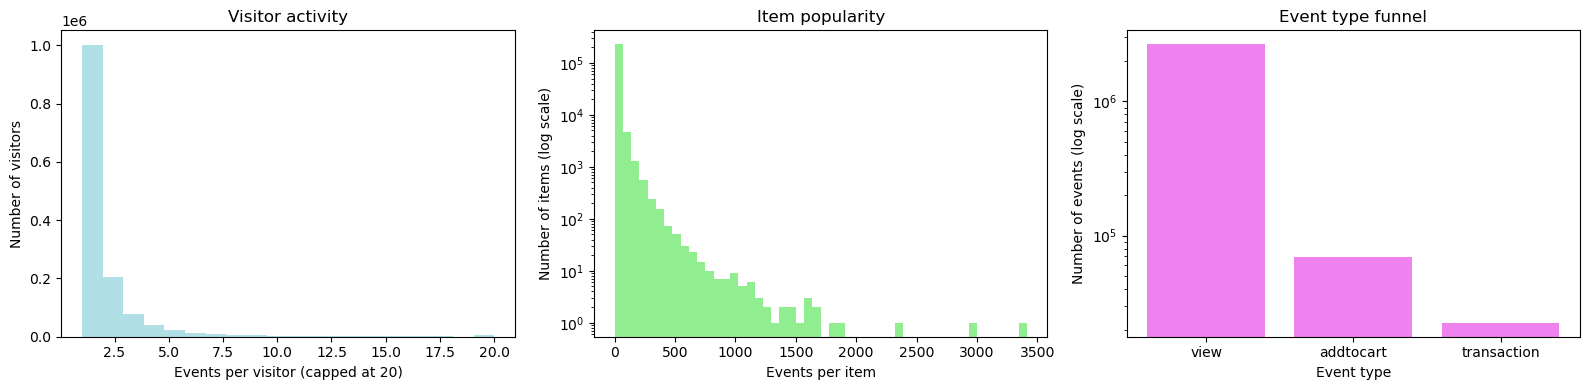

In [9]:
import matplotlib.pyplot as plt

# Recompute the distributions so this cell also works on its own.
events_per_visitor = events.groupby('user_id').size()
item_popularity = events.groupby('item_id').size()

# Count the three event types and keep them in funnel order.
event_counts = events['event'].value_counts().reindex(['view', 'addtocart', 'transaction'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: visitor activity.
# The x-axis is capped at 20 so that a few extremely active visitors do not flatten the plot.
axes[0].hist(events_per_visitor.clip(upper=20), bins=20, color='powderblue')
axes[0].set_title('Visitor activity')
axes[0].set_xlabel('Events per visitor (capped at 20)')
axes[0].set_ylabel('Number of visitors')

# Plot 2: item popularity.
# A log scale on the y-axis shows both the many rarely-seen items and the few very popular ones in one figure.
axes[1].hist(item_popularity, bins=50, color='lightgreen')
axes[1].set_yscale('log')
axes[1].set_title('Item popularity')
axes[1].set_xlabel('Events per item')
axes[1].set_ylabel('Number of items (log scale)')

# Plot 3: event-type funnel.
# A log scale is used because views outnumber the other two types by a large factor.
axes[2].bar(event_counts.index, event_counts.values, color='violet')
axes[2].set_yscale('log')
axes[2].set_title('Event type funnel')
axes[2].set_xlabel('Event type')
axes[2].set_ylabel('Number of events (log scale)')

plt.tight_layout()
plt.show()

### Interpretation

All three distributions are strongly skewed, which is typical for e-commerce data.

**Visitor activity** is extremely right-skewed. The first bar dominates the plot: the large majority of visitors produce only one or two events, and the number of visitors collapses almost to zero after that, with only a thin tail of more active visitors reaching the capped end at 20. This is the visual confirmation of the low median seen in section 2.1, and it is the reason the minimum-interaction filter removes so many visitors. Most visitors simply do not generate enough events to reveal a preference pattern.

**Item popularity** shows a clear long-tail pattern. On the log-scaled y-axis, a very large number of items are interacted with only a handful of times, while a small number of items receive hundreds or even thousands of events, stretching out to roughly 3,400. The smooth decay across the log scale is the signature of a long-tail distribution. This confirms why a minimum-support filter for items is needed: items in the long tail have too few interactions for the models to learn a reliable pattern from.

**Event type funnel** drops steeply from views to transactions. Even on a log-scaled y-axis each step down is clearly lower than the one before, which shows how many times rarer add-to-carts and transactions are than views. The visual ordering of the three bars supports the ordinal proxy rating in section 3: the rarer an action is, the stronger the intent it signals, so views, add-to-carts and transactions are weighted 1, 2 and 3 respectively.

### 2.4 Understanding the user identifier

Before using the visitor as the user unit, I need to understand what a `visitorid` represents. Unlike Diginetica, every event here has a `visitorid` and there is no session id, so the visitor is the only available user unit. The question is therefore not whether to use it, but whether it behaves like a real returning user or like a one-off visit. Because the data spans about four and a half months, I answer this by counting how many distinct days each visitor is active. A visitor active on several different days is a genuinely returning user, which is exactly the signal collaborative filtering can exploit.

In [10]:
# Convert the millisecond timestamp to a calendar date (day-level).
events['date'] = pd.to_datetime(events['ts'], unit='ms').dt.date

# For each visitor, count how many distinct days they are active.
days_per_visitor = events.groupby('user_id')['date'].nunique()

# Average and spread of active days per visitor.
print("Active days per visitor:")
print(days_per_visitor.describe(), "\n")

# Share of visitors that return on more than one day.
print("Share of visitors active on >1 day:", f"{(days_per_visitor > 1).mean():.2%}")

# Same question, but restricted to the visitors that survive the >=3 events filter, since those are the ones that actually reach the models.
active = events_per_visitor[events_per_visitor >= 3].index
days_active_sub = days_per_visitor.loc[active]
print("\nAmong visitors with >=3 events:")
print("  count:", len(days_active_sub))
print("  share active on >1 day:", f"{(days_active_sub > 1).mean():.2%}")
print("  mean active days:", round(days_active_sub.mean(), 2))

Active days per visitor:
count    1.407580e+06
mean     1.171894e+00
std      9.281007e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.310000e+02
Name: date, dtype: float64 

Share of visitors active on >1 day: 10.21%

Among visitors with >=3 events:
  count: 200028
  share active on >1 day: 45.38%
  mean active days: 1.94


### Interpretation

To check what a `visitorid` represents, I counted how many distinct days each visitor is active over the four-and-a-half-month period. Across all 1,407,580 visitors, returning is rare: the median visitor is active on a single day, and only 10.21% are active on more than one day. Taken on its own, this would suggest that most visitors are one-off and carry little user-level information, which matches the very low event counts seen in section 2.1.

The picture changes sharply once the minimum-interaction filter is taken into account. Among the 200,028 visitors with at least three events, 45.38% are active on more than one day, and these visitors are active on 1.94 different days on average. So nearly half of the visitors that actually reach the models are genuine returning users, rather than single-visit ones. This is an important justification for the modelling choice: the filter does not just remove low-activity visitors, it also concentrates the data on the visitors who return and therefore reveal a stable preference pattern. Using the `visitorid` as the user unit is well supported, because every event carries one and the retained visitors behave like real recurring users. This mirrors the role that the session played for Diginetica, but here the unit is an actual visitor tracked across multiple days.

### 2.5 Outlier inspection

The descriptive statistics in section 2.1 already showed a few extreme values: one visitor with 7,757 events and one item with 3,412. Before cleaning, these extremes are inspected to decide whether they should be treated as outliers and removed. For a recommender system this matters, because a single hyper-active visitor (for example a bot or a crawler) can interact with many unrelated items and distort the item similarities. The most active visitors and most popular items are listed here so that decision can be made on evidence rather than assumed.

In [11]:
# Look at the most active visitors and the most popular items to judge the extreme tail.
print("Top 10 most active visitors (events):")
print(events_per_visitor.sort_values(ascending=False).head(10).to_string(), "\n")

print("Top 10 most popular items (events):")
print(item_popularity.sort_values(ascending=False).head(10).to_string(), "\n")

# What share of all events comes from the very top visitors? (a few visitors dominating would be a concern)
top_share = events_per_visitor.sort_values(ascending=False).head(10).sum() / len(events)
print(f"Share of all events from the top 10 visitors: {top_share:.2%}")

Top 10 most active visitors (events):
user_id
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
371606     2345
286616     2252
684514     2246
892013     2024
861299     1991 

Top 10 most popular items (events):
item_id
187946    3412
461686    2978
5411      2334
370653    1854
219512    1800
257040    1647
298009    1642
96924     1633
309778    1628
384302    1608 

Share of all events from the top 10 visitors: 1.12%


### Interpretation

The most active visitors are extreme on their own, with the top one producing 7,757 events, but together the top 10 visitors only account for 1.12% of all events. There is no small group of visitors that dominates the data, so removing them as outliers would change very little while throwing away real interactions. The most popular items (up to 3,412 events) look like the natural head of the long-tail distribution already seen in section 2.3, not measurement errors, so I do not see them as outliers to remove either.

Based on this, the extreme values are kept rather than removed, for two reasons. First, the minimum-interaction filtering in section 4 already cleans up the noisy low end of the data (the visitors and items with too few interactions), which is where I think the real data-quality risk lies. Second, the item-based model uses a similarity-weighted average over a small set of neighbours, so even a single hyper-active visitor cannot really dominate a prediction the way it could in a method that treats all interactions equally. Removing the top visitors was considered, but in the end it seemed unnecessary, and I am noting that choice here so it is explicit rather than just assumed.

### 2.5 Correlation and relationship analysis

Finally, I check whether the three event types are related to each other at the item level. The question relevant for a recommender is whether items that are viewed often are also added to cart and bought often, because a strong relationship would justify treating a view as a weaker but still meaningful signal of preference. This replaces the price-based analysis used for Diginetica, since Retail Rocket has no usable price column. One table is built per item with its number of views, add-to-carts and transactions, after which the correlations between them are computed.

In [17]:
# Count each event type per item by pivoting the event column into columns.
item_funnel = events.pivot_table(index='item_id', columns='event',
                                 values='ts', aggfunc='size', fill_value=0)

# Rename to clear column names and keep a fixed order.
item_funnel = item_funnel.rename(columns={'view': 'n_views', 'addtocart': 'n_addtocart', 'transaction': 'n_transaction'})
item_funnel = item_funnel[['n_views', 'n_addtocart', 'n_transaction']]

print(item_funnel.describe())

# Spearman (rank-based) correlation is used instead of Pearson because all three counts are strongly right-skewed.
corr = item_funnel.corr(method='spearman')
print("\nSpearman correlation matrix:")
print(corr.round(3))

event        n_views    n_addtocart  n_transaction
count  235061.000000  235061.000000  235061.000000
mean       11.334556       0.294953       0.095537
std        35.394268       1.826829       0.738321
min         0.000000       0.000000       0.000000
25%         1.000000       0.000000       0.000000
50%         3.000000       0.000000       0.000000
75%         9.000000       0.000000       0.000000
max      3410.000000     306.000000     133.000000

Spearman correlation matrix:
event          n_views  n_addtocart  n_transaction
event                                             
n_views          1.000        0.415          0.326
n_addtocart      0.415        1.000          0.681
n_transaction    0.326        0.681          1.000


### Interpretation

The describe table shows that the three event types are very unevenly spread across items. The average item receives about 11.3 views but only 0.29 add-to-carts and 0.10 transactions, and the median item has 0 of both: most items are never added to cart or bought at all, while a small number of items concentrate almost all of the deeper events (up to 306 add-to-carts and 133 transactions for a single item). This is the same long-tail pattern seen in section 2.3, now visible across all three funnel stages.

The Spearman correlations confirm that the funnel is internally consistent. All three event types are positively correlated, and the strength follows the funnel order: steps that are closer together correlate more strongly than steps that are further apart. Add-to-cart and transaction correlate most strongly (0.681), which makes sense because adding to cart is the step that directly precedes buying. Views correlate moderately with add-to-carts (0.415) and somewhat less with transactions (0.326), but both correlations are clearly positive. This supports using a view as a weaker but still meaningful signal of preference in the proxy rating of section 3: items that attract more views also tend to attract more carts and purchases, even though the relationship weakens across the funnel.

The analysis also confirms that the useful information in this dataset lies in interaction patterns rather than item content. Both techniques used in this project rely on those patterns: SVD (technique A) factorizes the user–item interaction matrix, and item-based KNN (technique D) measures item similarity from the users that items share, not from item attributes such as category. This is why the category tree and item properties are not used as model features.

## 3. Data cleaning and interaction construction

The raw files do not contain explicit ratings, so a single table of (user, item, rating) interactions has to be built before collaborative filtering can be applied. Based on the EDA, two choices are made here, both supported by evidence:

1. The visitor is used as the user unit, because every event carries a `visitorid` and the retained visitors behave like real returning users (section 2.4).
2. A proxy rating is derived from the event type. As explained in the lecture on implicit feedback, a rating can be derived from user actions, where a stronger action counts more than a weaker one (Bhaumik, 2024b). The three event types form a funnel where each step is both rarer and a deeper signal of intent (section 2.1), and the funnel is internally consistent because the three steps are positively correlated at the item level (section 2.5). A view is therefore given a weight of 1, an add-to-cart a weight of 2, and a transaction a weight of 3.

Creating this proxy rating and the purchase label are also feature creation steps: both are new features built from the raw event logs.

In [18]:
import numpy as np

# Define the weights for the proxy rating, following the funnel: stronger action = stronger signal.
VIEW_W, ADDTOCART_W, TRANSACTION_W = 1.0, 2.0, 3.0

# Map each event type to its weight, then build one long table of interactions.
weight_map = {'view': VIEW_W, 'addtocart': ADDTOCART_W, 'transaction': TRANSACTION_W}
inter = events[['user_id', 'item_id', 'event']].copy()
inter['rating'] = inter['event'].map(weight_map)

# If the same visitor interacted with an item several times, keep the strongest signal.
inter = inter.groupby(['user_id', 'item_id'], as_index=False)['rating'].max()

# Add a binary purchase label. This is used later for the classification metrics of the item-based technique (precision, recall, F1, AUC-ROC).
inter['purchased'] = (inter['rating'] == TRANSACTION_W).astype(int)

print(inter.head())
print("Total interactions before filtering:", len(inter))
print("Purchases (transaction interactions):", int(inter['purchased'].sum()))

   user_id  item_id  rating  purchased
0        0    67045     1.0          0
1        0   285930     1.0          0
2        0   357564     1.0          0
3        1    72028     1.0          0
4        2   216305     1.0          0
Total interactions before filtering: 2145179
Purchases (transaction interactions): 21270


### Interpretation

Each row now represents one user–item interaction with a single proxy rating, and a `purchased` flag that marks whether that interaction reached a transaction. The first rows show visitor 0 interacting with three different items at a rating of 1.0, which is the expected shape: one visitor interacting with several items, most of them through views.

After mapping each event to its weight and keeping the strongest signal per user–item pair, there are 2,145,179 interactions in total. This is lower than the original 2,756,101 events, which is expected: when a visitor interacts with the same item more than once, those events collapse into a single row that keeps the highest weight. The same effect explains why the number of purchase interactions (21,270) is slightly lower than the 22,457 raw transaction events from section 2.1, since repeated transactions on the same item by the same visitor now count once. Keeping the strongest signal is the right choice here, because a single user–item pair should carry one preference value, and the deepest action in the funnel is the most informative one.

## 4. Filtering rare items and inactive visitors

Two practical problems remain. The full interaction matrix is very large, and the EDA showed that many items and visitors appear only once, which gives the models too little information to learn from. Following a common preprocessing step for interaction data, items that occur fewer than five times and visitors with fewer than three interactions are removed. The minimum of three per visitor is the same threshold motivated in section 2.1: it is the smallest count that lets each visitor be split across the training, validation and test set. The filter-impact preview in that section already showed that this removes most visitors but keeps close to half of the events, and the exact figures are reported here on the deduplicated interactions. This filtering improves data quality and keeps the similarity computation for Item-KNN feasible within memory.

In [19]:
# Minimum support: items must appear at least 5 times, visitors need at least 3 interactions.
# The minimum of 3 lets each visitor be split across the train, validation and test sets (one interaction per set at minimum).
MIN_ITEM, MIN_USER = 5, 3

# Keep only items that occur often enough to be learned reliably.
item_counts = inter['item_id'].value_counts()
inter = inter[inter['item_id'].isin(item_counts[item_counts >= MIN_ITEM].index)]

# Keep only visitors with enough interactions (a single interaction says little).
user_counts = inter['user_id'].value_counts()
inter = inter[inter['user_id'].isin(user_counts[user_counts >= MIN_USER].index)]

# Report the size and sparsity of the resulting dataset.
n_users = inter['user_id'].nunique()
n_items = inter['item_id'].nunique()
density = len(inter) / (n_users * n_items)

print("Interactions after filtering:", len(inter))
print("Visitors:", n_users, "| Items:", n_items)
print(f"Matrix density: {density:.6%}")
print("Purchases kept:", int(inter['purchased'].sum()))

Interactions after filtering: 589168
Visitors: 102292 | Items: 65144
Matrix density: 0.008841%
Purchases kept: 13555


In [20]:
# Verify that every retained visitor still has at least MIN_USER interactions, since the item filter could in principle have pushed some visitors below the threshold.
post = inter['user_id'].value_counts()
print("Smallest interaction count per visitor:", post.min())
print("Visitors below MIN_USER:", int((post < MIN_USER).sum()))

Smallest interaction count per visitor: 3
Visitors below MIN_USER: 0


### Interpretation

After filtering, the dataset contains 589,168 interactions across 102,292 visitors and 65,144 items. Removing rare items and visitors with fewer than three interactions took out a large part of the data, which was also the noisiest: items seen fewer than five times and visitors that produced almost no events. As the preview in section 2.1 anticipated, the cut falls mainly on visitors, since the majority of them had only one or two events. The minimum of three interactions per visitor is also needed so that each visitor can later be divided over a training, validation and test set.

The order of the two filters could in principle leave a visitor below the threshold, because removing rare items can lower a visitor's interaction count. The check confirms this did not happen: after both filters the smallest interaction count per visitor is exactly three, and no visitor falls below the minimum. The filters are therefore stable in this order and do not need to be repeated, so the per-visitor split assumption holds for every retained visitor.

The matrix density is only 0.0088%, so about 99.99% of all possible visitor–item pairs are unobserved. This extreme sparsity is normal for e-commerce interaction data and is the central challenge for collaborative filtering: the models must predict preferences from very few observed signals. It also explains why filtering is necessary, since a slightly denser and cleaner matrix makes both the similarity computation (Item-KNN) and the factorization (SVD) more reliable and faster to run. Finally, 13,555 purchases remain, which confirms that enough positive purchase labels survive the cleaning to support the classification metrics used later for the item-based technique.

## 5. Feature engineering: encoding visitor and item IDs

The models work with matrix positions, not with the raw id numbers, so the visitor and item ids are mapped to contiguous integer indices (0 to n-1). This encoding is done after filtering on purpose: by encoding the filtered ids, the indices have no gaps, which keeps the interaction matrix as small and memory-efficient as possible.

In [21]:
# Get the unique visitors and items that remain after filtering.
user_ids = inter['user_id'].unique()
item_ids = inter['item_id'].unique()

# Build lookup dictionaries from the original id to a contiguous index (0..n-1).
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
item_to_idx = {iid: i for i, iid in enumerate(item_ids)}

# Apply the mapping to create new index columns.
inter['user_idx'] = inter['user_id'].map(user_to_idx)
inter['item_idx'] = inter['item_id'].map(item_to_idx)

print("Encoded visitors:", len(user_to_idx))
print("Encoded items:", len(item_to_idx))
print(inter[['user_id', 'user_idx', 'item_id', 'item_idx', 'rating', 'purchased']].head())

Encoded visitors: 102292
Encoded items: 65144
   user_id  user_idx  item_id  item_idx  rating  purchased
0        0         0    67045         0     1.0          0
1        0         0   285930         1     1.0          0
2        0         0   357564         2     1.0          0
4        2         1   216305         3     1.0          0
5        2         1   259884         4     1.0          0


### Interpretation

The encoding produced 102,292 visitor indices and 65,144 item indices, which matches exactly the number of visitors and items reported after filtering in section 4. This confirms that every remaining visitor and item received a unique, contiguous index from 0 upwards.

The preview shows that the original ids are now paired with small index numbers. Visitor 0 maps to `user_idx` 0 across three items at `item_idx` 0, 1 and 2, and the next retained visitor (original id 2) becomes `user_idx` 1. The original id 1 is absent here because that visitor was removed by the filter in section 4, and the index simply continues without leaving a gap. These indices are what the models use as row and column positions in the interaction matrix, while the original ids are kept in the table so results can still be traced back to real visitors and items.

## 6. Save the processed data

Finally, the cleaned and encoded interaction table is saved to a file. The modelling notebook loads this file directly, so the cleaning and feature engineering steps do not have to be repeated there. The saved table has the same structure as the processed Diginetica file, with a visitor index instead of a session index, so the modelling notebook can follow the same steps for both datasets.

In [22]:
# Save the processed interactions so the modelling notebook can load them directly.
inter.to_parquet("retailrocket_interactions.parquet", index=False)
print("Saved cleaned interactions to retailrocket_interactions.parquet")
print("Final shape:", inter.shape)

Saved cleaned interactions to retailrocket_interactions.parquet
Final shape: (589168, 6)


## Use of AI Tools

AI tools were used in a supporting role only, not to generate the solution. They were consulted to clarify data cleaning, EDA and feature engineering concepts, to help with debugging, to explain how certain methods or functions work when needed, and to help make sure that the EDA steps and their interpretations were worded clearly and correctly. 